---
title: "DEDL_DEFAIR_readers_writers_tour" 
subtitle: "This notebook shows how to start working with DEFAIR (Destination Earth Framework for preparing AI-Ready Data)"
author: "Author: Peter Boxall(Oxidian)"
tags: [DEFAIR, EUMETSAT,zarr,AI-Ready-data]
thumbnail: img/EUMETSAT.png 
license: MIT
copyright: "© 2026 EUMETSAT"
---

<!-- Optional: Add a JupyterHub launch link here. If you don’t have one, you can remove this block. -->

<div style="margin: 6px 0;">
  <a href="https://jupyter.central.data.destination-earth.eu/user-redirect/lab/tree/DATA_PROCESSING/DEFAIR/DEDL_DEFAIR_readers_writers_tour.ipynb" target="_blank" style="text-decoration: none;">
    <span class="launch">🚀 Launch in JupyterHub</span>
  </a>
</div>

# DEDL_DEFAIR_readers_writers_tour

DEFAIR provides a unified interface for working with multiple EUMETSAT product families, despite their very different internal file structures and formats.

With a single call to `Dataset.from_source()`, users can read data from eight supported EUMETSAT products, including products distributed as EPS Native (`.nat`), NetCDF, and SAFE packages. DEFAIR automatically handles the product-specific parsing and harmonization that would otherwise require custom reader implementations.

Likewise, a common `to_file()` interface enables exporting datasets to multiple output formats without changing the processing workflow.


### Contents
- **Objective:** Demonstrate how DEFAIR simplifies access to heterogeneous EUMETSAT products through a consistent API for reading, processing, and writing Earth observation data.
- **Data Sources:** EUMETSAT Earth observation products distributed in various native formats, including EPS Native (`.nat`), NetCDF, and SAFE containers.
- **Methods:** 
    - Load different product families using `Dataset.from_source()`.
    - Access data through a common dataset abstraction.
    - Export results using the `to_file()` interface.
    - Compare workflows across heterogeneous source formats.
- **Prerequisites:** Before executing the notebook, ensure that the following requirements are met:

    - Running on Insula
        - A valid <a href="https://platform.destine.eu/"> Destination Earth (DestinE) </a> user account is required.
        - The "Python (defair)" kernel must be selected to run this notebook.

    - Running on DEDL Stack
        - A valid <a href="https://platform.destine.eu/"> Destination Earth (DestinE) </a> user account is required.
        - Access to <a href="https://application.data.destination-earth.eu/"> EDGE Services</a> EDGE Services is required.
        - The "Python (defair)" kernel must be selected to run this notebook.
- **Expected Output:** 
By the end of this notebook, users will understand how to:
- Read multiple EUMETSAT product types using a single API.
- Work with a harmonized dataset structure regardless of source format.
- Export datasets to different output formats using a common workflow.

## Setup

In [4]:
import os
import shutil
from pathlib import Path

import numpy as np
import xarray as xr
import rasterio
from IPython.display import Image as IPyImage

from defair_data.core import Dataset
from defair_data.dask_manager import get_dask_client, close_dask_client
from defair_data.readers import list_readers
from defair_data.writers import list_writers
from defair.plugin_manager import load_source

import sys


get_dask_client(n_workers=1, threads_per_worker=4, memory_limit="8GB", processes=False)
OUTPUT = Path("output"); OUTPUT.mkdir(exist_ok=True)

ROOT = "//s3.central.data.destination-earth.eu"
s3 = load_source("s3")
structures = {}

print(f"{len(list_readers())} readers, {len(list_writers())} writers available")

2026-07-28 16:22:59.875 | DEBUG    | defair_data.dask_manager:__init__:649 - DaskClientManager initialized
2026-07-28 16:22:59.876 | DEBUG    | defair_data.dask_manager:_discover_existing_client:774 - No client found via Client.current()
2026-07-28 16:22:59.877 | INFO     | defair_data.dask_manager:acquire_client:688 - Creating new Dask client (ref_count: 1)
2026-07-28 16:23:02.481 | INFO     | defair_data.dask_manager:_create_client:873 - Dask client created: <Client: 'inproc://10.100.4.25/780/1' processes=1 threads=4, memory=7.45 GiB>
2026-07-28 16:23:02.483 | DEBUG    | defair_data.dask_manager:_create_client:874 - Client dashboard: http://10.100.4.25:8787/status
2026-07-28 16:23:04.115 | DEBUG    | defair.plugin_manager:_load_plugin:146 - Loading plugin 's3' from group 'defair_data.sources'
2026-07-28 16:23:04.115 | DEBUG    | defair_data.sources.s3.s3_base:__init__:129 - Using custom S3 endpoint: https://eodata.dataspace.copernicus.eu/


51 readers, 7 writers available


51 readers, 7 writers available


## 1. MSG SEVIRI — geostationary disk vs EPSG:4326

Proprietary EUMETSAT binary; geolocation comes from the geostationary projection (the reader is **auto-detected**, no `reader=`). The same IR 10.8 µm scene is shown on its native geostationary full disk and reprojected to EPSG:4326 lat/lon.

In [5]:
msg = Dataset.from_source("s3://datalake-demo-data/defair-demo-data/MSG3-SEVI-MSG15-0100-NA-20260626111243.441000000Z-NA.nat",
    source="s3",
    source_kwargs={
        "endpoint_url": "https://s3.central.data.destination-earth.eu",
        "aws_access_key_id": "f27646e0b43e4fc29803eeb8926b9b4a",
        "aws_secret_access_key": "c416629cf9c544e1ab367b6ad8212a1b"
    })
structures["MSG SEVIRI"] = msg

2026-07-28 16:30:17.601 | DEBUG    | defair_data.readers:find_reader_for_path:67 - Plugin 'msg15nat' can handle 's3://datalake-demo-data/defair-demo-data/MSG3-SEVI-MSG15-0100-NA-20260626111243.441000000Z-NA.nat' (priority: 80)
2026-07-28 16:30:19.764 | INFO     | defair_data.readers:find_reader_for_path:80 - Selected reader plugin 'msg15nat' for path: s3://datalake-demo-data/defair-demo-data/MSG3-SEVI-MSG15-0100-NA-20260626111243.441000000Z-NA.nat
2026-07-28 16:30:19.765 | INFO     | defair_data.core:_from_single_source:663 - Auto-detected reader 'msg15nat' for path: s3://datalake-demo-data/defair-demo-data/MSG3-SEVI-MSG15-0100-NA-20260626111243.441000000Z-NA.nat
2026-07-28 16:30:19.779 | DEBUG    | defair.plugin_manager:_load_plugin:146 - Loading plugin 'msg15nat' from group 'defair_data.readers'
2026-07-28 16:30:19.780 | DEBUG    | defair.cf_history_mixin:_build_history_entry:194 - Built history entry: 2026-07-28T16:30:19.779984+00:00: Read operation [DEFAIR v0.3.0rc5:MSG15NativeRead

## 2. MTG FCI — a full disk assembled from chunks

FCI scans the Earth in horizontal strips, south to north; each strip is a separate
**chunk file**, about 40 per full disk.

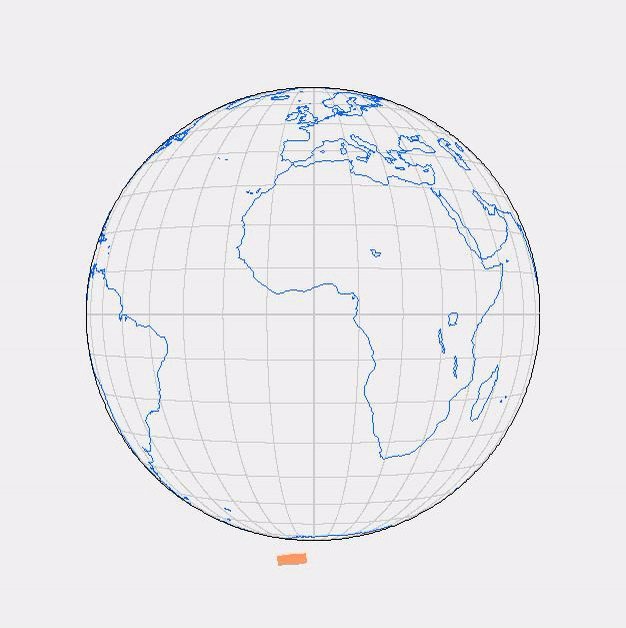

In [7]:
IPyImage(filename="assets/mtg_fci_scanning_fdss.gif")